#Importation des données dans Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Importation des bibliothèques et les métriques à utiliser

In [ ]:
!pip install prophet

In [ ]:
!pip install plotly

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.style.use('fivethirtyeight') # For plots
from sklearn.model_selection import TimeSeriesSplit
df = pd.read_csv('drive/MyDrive/PJME_hourly.csv')

#Manipulation des données

In [ ]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [ ]:
df.isna().sum()

,0
Datetime,0
PJME_MW,0


In [ ]:
df=df.set_index('Datetime') #Indexation de la colonne Datetime
df.index=pd.to_datetime(df.index) #Conversion du type d'un objet vers datetime

#Visualisation des données

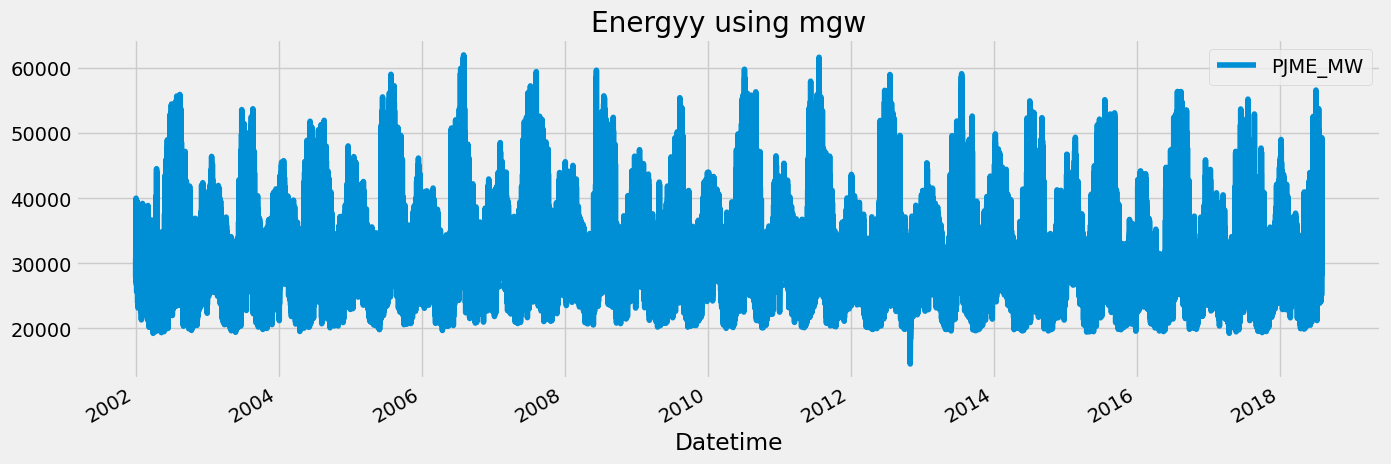

In [ ]:
color_pal = sns.color_palette()
df.plot(figsize=(15,5),style= '-',color=color_pal[0], title='Energyy using mgw')
plt.show()

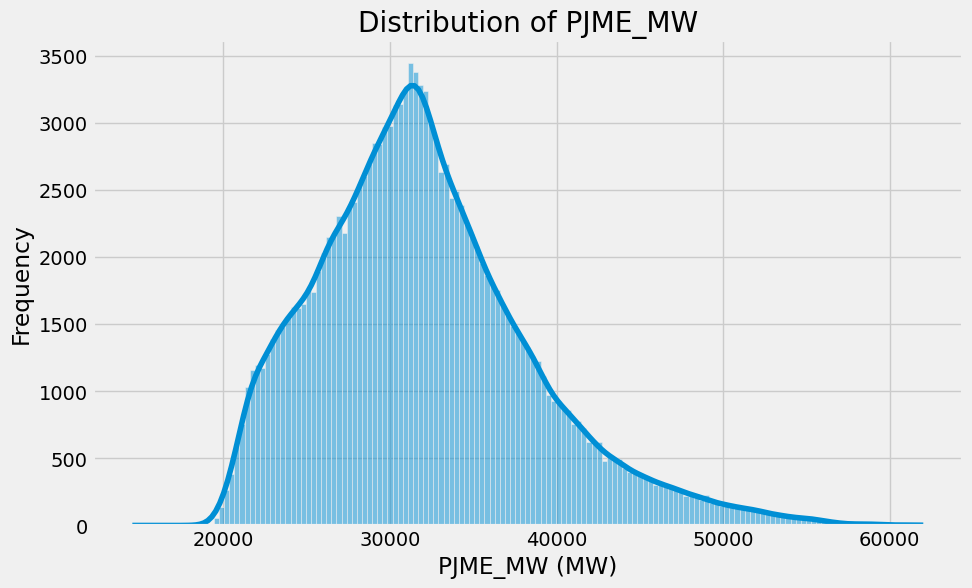

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PJME_MW'], kde=True, color=color_pal[0])
plt.title('Distribution of PJME_MW')
plt.xlabel('PJME_MW (MW)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Séparer la dataframe en train set (avant 2015) et test set (après 2015)
train_set=df.loc[df.index< '2015-01-01']
test_set=df.loc[df.index>='2015-01-01']

In [ ]:
train_set.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'PJME_MW':'y'}).head()

,ds,y
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
model = Prophet()
model.fit(train_set.reset_index() \
              .rename(columns={'Datetime':'ds',
                               'PJME_MW':'y'}))

DEBUG:cmdstanpy:input tempfile: /tmp/tmpc6oea_ld/nk913vki.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc6oea_ld/kcqfj_i0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86943', 'data', 'file=/tmp/tmpc6oea_ld/nk913vki.json', 'init=/tmp/tmpc6oea_ld/kcqfj_i0.json', 'output', 'file=/tmp/tmpc6oea_ld/prophet_models9iv_h9h/prophet_model-20250828105306.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:53:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:56:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Predict on training set with model
pjme_test_fcst = model.predict(df=test_set.reset_index() \
                                   .rename(columns={'Datetime':'ds'}))

In [ ]:
pjme_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 00:00:00,31219.254294,25904.419529,35017.145263,31219.254294,31219.254294,-815.442591,-815.442591,-815.442591,-2412.316532,...,1288.725606,1288.725606,1288.725606,308.148335,308.148335,308.148335,0.0,0.0,0.0,30403.811703
1,2015-01-01 01:00:00,31219.217903,23811.148593,32887.905374,31219.217903,31219.217903,-2839.772695,-2839.772695,-2839.772695,-4430.472014,...,1281.281922,1281.281922,1281.281922,309.417397,309.417397,309.417397,0.0,0.0,0.0,28379.445208
2,2015-01-01 02:00:00,31219.181511,22329.853659,31205.508263,31219.181511,31219.181511,-4344.026758,-4344.026758,-4344.026758,-5927.279788,...,1272.525092,1272.525092,1272.525092,310.727938,310.727938,310.727938,0.0,0.0,0.0,26875.154753
3,2015-01-01 03:00:00,31219.145120,21432.274967,30379.965893,31219.145120,31219.145120,-5215.628487,-5215.628487,-5215.628487,-6790.271818,...,1262.563347,1262.563347,1262.563347,312.079985,312.079985,312.079985,0.0,0.0,0.0,26003.516634
4,2015-01-01 04:00:00,31219.108729,21454.836652,30249.265565,31219.108729,31219.108729,-5357.155764,-5357.155764,-5357.155764,-6922.149585,...,1251.520256,1251.520256,1251.520256,313.473565,313.473565,313.473565,0.0,0.0,0.0,25861.952965


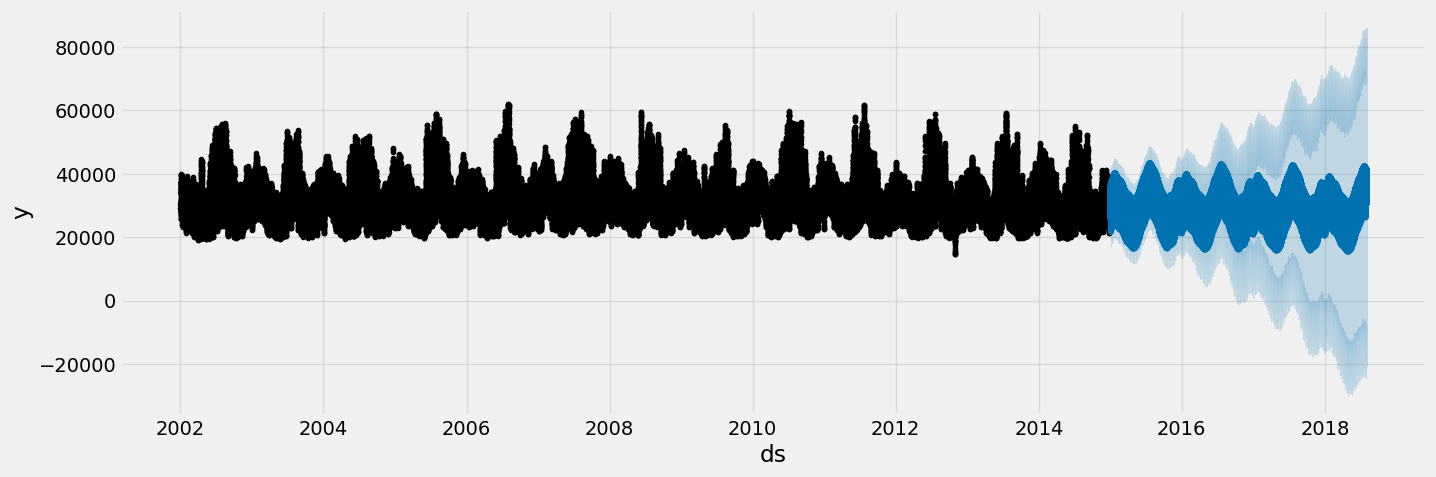

In [ ]:
# Plot the forecast
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
fig = model.plot(pjme_test_fcst,
                 ax=ax)
plt.show()

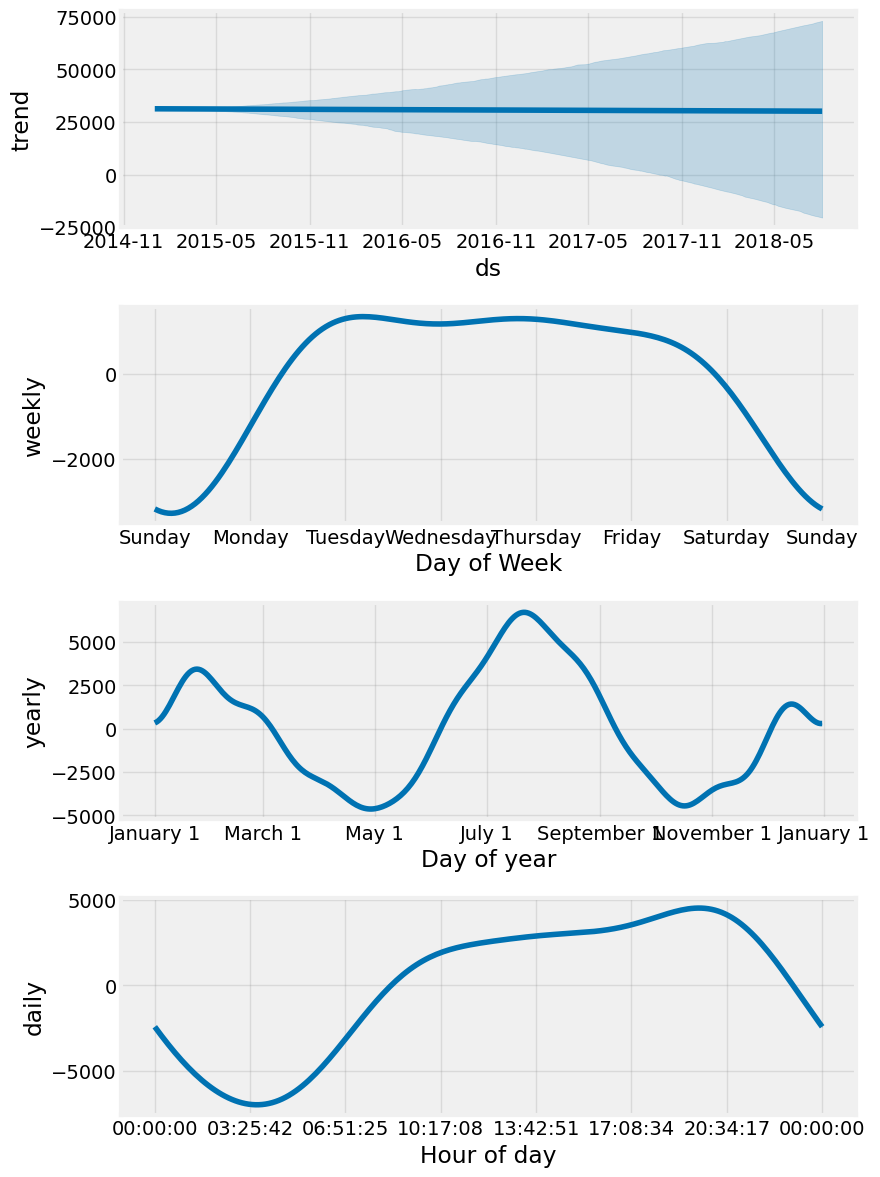

In [ ]:
# Plot the components of the model
fig = model.plot_components(pjme_test_fcst)

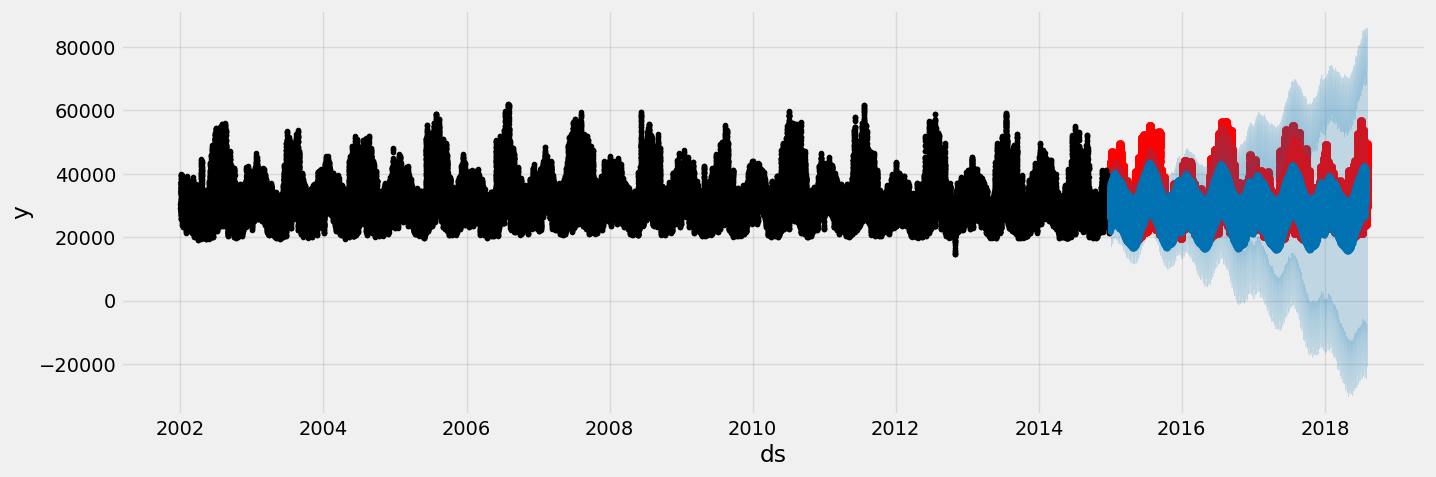

In [ ]:
# Plot the forecast with the actuals
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax.scatter(test_set.index, test_set['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)

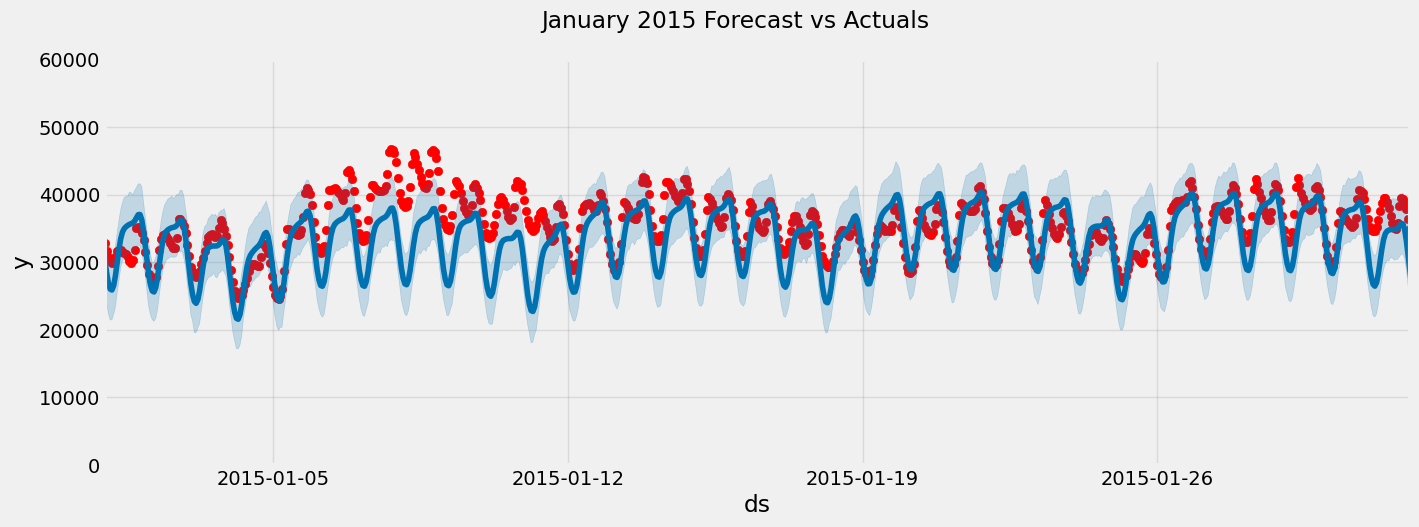

In [ ]:
# Plot the forecast with the actuals
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax.scatter(test_set.index, test_set['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=pd.to_datetime('01-01-2015'),
              upper=pd.to_datetime('02-01-2015'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('January 2015 Forecast vs Actuals')

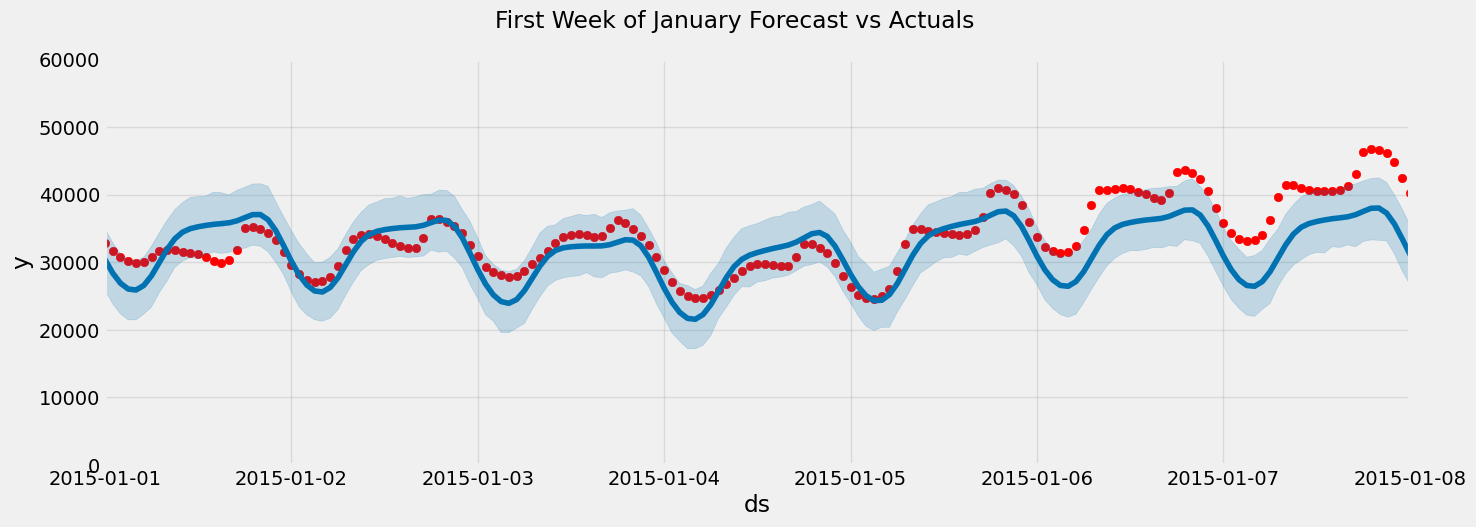

In [ ]:
# Plot the forecast with the actuals
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax.scatter(test_set.index, test_set['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=pd.to_datetime('01-01-2015'), upper=pd.to_datetime('01-08-2015'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('First Week of January Forecast vs Actuals')

In [ ]:
def create_features(df):
    """
    Create time series features from datetime index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

train = df.loc[df.index < '2015-01-01']
test = df.loc[df.index >= '2015-01-01']

FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year',
            'dayofyear', 'weekofyear']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [ ]:
import xgboost as xgb
reg = xgb.XGBRegressor(n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       learning_rate=0.01)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=1)

[0]	validation_0-rmse:6407.33076	validation_1-rmse:6479.90493
[1]	validation_0-rmse:6362.96293	validation_1-rmse:6438.65823
[2]	validation_0-rmse:6319.23421	validation_1-rmse:6398.14025
[3]	validation_0-rmse:6275.99765	validation_1-rmse:6358.53667
[4]	validation_0-rmse:6233.34612	validation_1-rmse:6319.61038
[5]	validation_0-rmse:6191.29330	validation_1-rmse:6281.54273
[6]	validation_0-rmse:6149.75348	validation_1-rmse:6243.67931
[7]	validation_0-rmse:6108.81597	validation_1-rmse:6206.62839
[8]	validation_0-rmse:6068.34314	validation_1-rmse:6169.31646
[9]	validation_0-rmse:6028.41038	validation_1-rmse:6133.15335
[10]	validation_0-rmse:5989.06847	validation_1-rmse:6097.56715
[11]	validation_0-rmse:5950.19978	validation_1-rmse:6062.50490
[12]	validation_0-rmse:5911.46461	validation_1-rmse:6027.51144
[13]	validation_0-rmse:5873.65015	validation_1-rmse:5993.71744
[14]	validation_0-rmse:5835.97155	validation_1-rmse:5959.88463
[15]	validation_0-rmse:5798.66923	validation_1-rmse:5926.94317
[1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
predictions = reg.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 13855072.227596926
Mean Absolute Error: 2883.6427521295523


# Task
Calculate and compare the performance of the Prophet and XGBoost models on the test set using RMSE, MAE, and MAPE metrics, and visualize their predictions against the actual values.

## Calculate prophet metrics

### Subtask:
Calculate RMSE, MAE, and MAPE for the Prophet model's predictions on the test set.


**Reasoning**:
Calculate and print the RMSE, MAE, and MAPE for the Prophet model using the test set predictions and actual values.



**Reasoning**:
The error indicates a type mismatch when calculating MAPE, likely due to the index of the test set. Aligning the indices of `test_set['PJME_MW']` and `pjme_test_fcst['yhat']` before calculating MAPE should resolve this issue.



In [ ]:
# Calculate metrics for Prophet model
prophet_mse = mean_squared_error(test_set['PJME_MW'], pjme_test_fcst['yhat'])
prophet_rmse = np.sqrt(prophet_mse)
prophet_mae = mean_absolute_error(test_set['PJME_MW'], pjme_test_fcst['yhat'])

# Align the actual and predicted values before calculating MAPE
actual_values = test_set['PJME_MW']
predicted_values = pjme_test_fcst.set_index('ds')['yhat']
aligned_actual, aligned_predicted = actual_values.align(predicted_values, join='inner')

# Calculate MAPE, handling potential division by zero
# Add a small epsilon to avoid division by zero in case actual_values contain zeros
epsilon = 1e-10
prophet_mape = np.mean(np.abs((aligned_actual - aligned_predicted) / (aligned_actual + epsilon))) * 100

print(f'Prophet Model - Mean Squared Error: {prophet_mse}')
print(f'Prophet Model - Root Mean Squared Error: {prophet_rmse}')
print(f'Prophet Model - Mean Absolute Error: {prophet_mae}')
print(f'Prophet Model - Mean Absolute Percentage Error: {prophet_mape}')

Prophet Model - Mean Squared Error: 43734606.60057608
Prophet Model - Root Mean Squared Error: 6613.2145436675555
Prophet Model - Mean Absolute Error: 5181.021480841299
Prophet Model - Mean Absolute Percentage Error: 9.62463489158451


## Align data for visualization

### Subtask:
Merge the actual test set values with the Prophet and XGBoost predictions to prepare for visualization.


**Reasoning**:
Create the `forecast_test` DataFrame, join it with `test_set`, rename the column, create `all_data`, and join it with `forecast_test` to prepare the dataframes for plotting.



In [ ]:
forecast_test = pjme_test_fcst.copy().set_index('ds')
test_and_forecast = test_set.join(forecast_test[['yhat']])
test_and_forecast = test_and_forecast.rename(columns={'PJME_MW': 'Actual'})
all_data = df.copy()
all_data = all_data.join(forecast_test[['yhat']])

## Visualize performance

### Subtask:
Create plots to visually compare the actual values, Prophet predictions, and XGBoost predictions.


**Reasoning**:
Create a plot to compare the actual values, Prophet predictions, and XGBoost predictions.



**Reasoning**:
The previous code failed because the index of `test_and_forecast` (which is used for the x-axis) and the `predictions` (XGBoost predictions) do not have the same dimension. This is likely due to an issue when creating `test_and_forecast`. I need to ensure that the indices of `test_and_forecast` and `predictions` match. I will re-create the `test_and_forecast` dataframe using `test` and the `predictions` which should have the same index.



**Reasoning**:
The error message "ValueError: cannot reindex on an axis with duplicate labels" indicates that there are duplicate index values in one of the dataframes being used for reindexing. This is likely in the `pjme_test_fcst` dataframe when setting the index to 'ds'. I need to investigate the `pjme_test_fcst` dataframe to identify and handle the duplicate indices before attempting to join it with the `test` dataframe. I will check for duplicate values in the 'ds' column of `pjme_test_fcst`.



In [ ]:
print(pjme_test_fcst['ds'].duplicated().sum())

3


**Reasoning**:
There are 3 duplicate entries in the 'ds' column of `pjme_test_fcst`. This is causing the reindexing error. To fix this, I will drop the duplicate rows from `pjme_test_fcst` before setting the index and joining with the `test` dataframe. Then I will attempt to plot again.



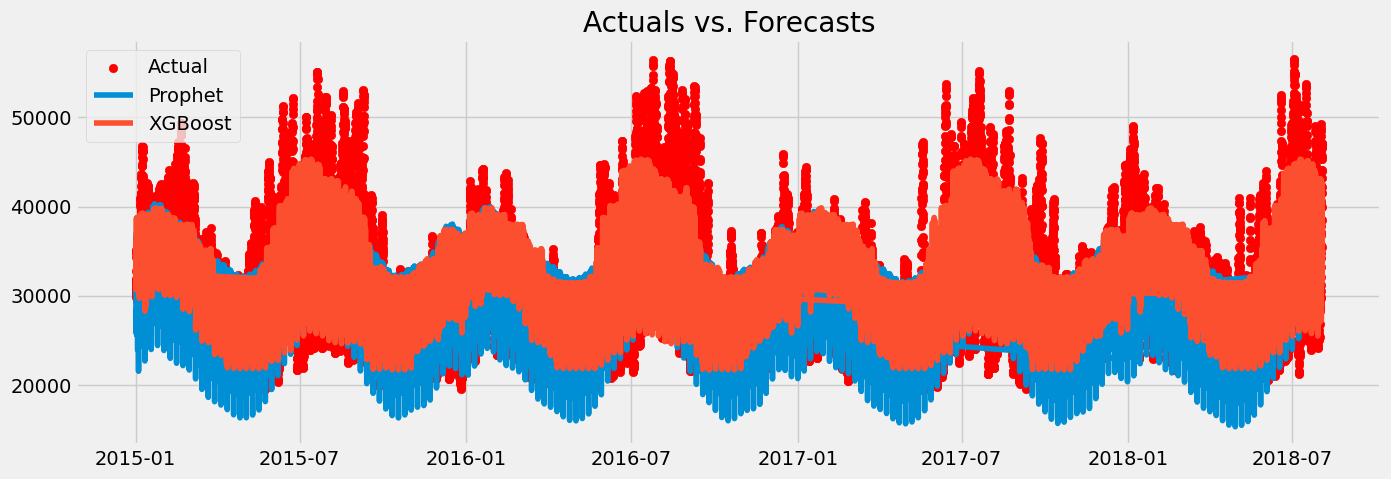

In [ ]:
# Drop duplicate 'ds' entries from pjme_test_fcst
pjme_test_fcst_unique = pjme_test_fcst.drop_duplicates(subset=['ds'])

# Re-create test_and_forecast using the test dataframe and predictions with unique indices
test_and_forecast = test.copy()
test_and_forecast['yhat_prophet'] = pjme_test_fcst_unique.set_index('ds')['yhat']
test_and_forecast['yhat_xgboost'] = predictions

f, ax = plt.subplots(1, figsize=(15, 5))
ax.scatter(test_and_forecast.index, test_and_forecast['PJME_MW'], color='r', label='Actual')
ax.plot(test_and_forecast.index, test_and_forecast['yhat_prophet'], label='Prophet')
ax.plot(test_and_forecast.index, test_and_forecast['yhat_xgboost'], label='XGBoost')
ax.set_title('Actuals vs. Forecasts')
ax.legend()
plt.show()

## Compare numerical metrics

### Subtask:
Present the calculated RMSE, MAE, and MAPE for both Prophet and XGBoost models side-by-side for numerical comparison.


**Reasoning**:
Create a DataFrame to compare the performance metrics of the Prophet and XGBoost models and display it.



In [ ]:
# Calculate RMSE for XGBoost
xgboost_rmse = np.sqrt(mse)

# Calculate MAPE for XGBoost, adding epsilon to avoid division by zero
epsilon = 1e-10
xgboost_mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100

# Create a DataFrame to store the metrics
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE'],
    'Prophet': [prophet_rmse, prophet_mae, prophet_mape],
    'XGBoost': [xgboost_rmse, mae, xgboost_mape]
})

# Display the DataFrame
display(metrics_df)

,Metric,Prophet,XGBoost
0,RMSE,6613.214544,3722.240216
1,MAE,5181.021481,2883.642752
2,MAPE,9.624635,9.165179


# Task
Integrate relevant holidays into the Prophet model for demand forecasting, retrain the model with the holidays, compare the performance of the model with and without holidays using RMSE, MAE, and MAPE, and visualize the predictions.

## Create holiday dataframe

### Subtask:
Create a pandas DataFrame containing the relevant holidays with 'holiday', 'ds', 'lower_window', and 'upper_window' columns.


**Reasoning**:
Create a pandas DataFrame containing the relevant holidays with 'holiday', 'ds', 'lower_window', and 'upper_window' columns as instructed.



In [ ]:
import holidays

# Define the year range for holidays
start_year = df.index.min().year
end_year = df.index.max().year

# Create a list of holidays for the specified year range
us_holidays = holidays.US(years=range(start_year, end_year + 1))

# Convert holidays to a pandas DataFrame
holidays_df = pd.DataFrame([(k, v) for k, v in us_holidays.items()], columns=['ds', 'holiday'])

# Add lower_window and upper_window columns
holidays_df['lower_window'] = 0
holidays_df['upper_window'] = 0

# Display the head of the holidays DataFrame
display(holidays_df.head())

,ds,holiday,lower_window,upper_window
0,2016-01-01,New Year's Day,0,0
1,2016-05-30,Memorial Day,0,0
2,2016-07-04,Independence Day,0,0
3,2016-09-05,Labor Day,0,0
4,2016-11-11,Veterans Day,0,0


## Re-train Prophet with holidays

### Subtask:
Initialize and fit the Prophet model on the training set, including the holiday dataframe.

**Reasoning**:
Initialize a Prophet model and add the `holidays_df` to it, then fit the model with the training data as instructed.

In [ ]:
# Initialize Prophet model with holidays
model_with_holidays = Prophet(holidays=holidays_df)

# Fit the model with the training data
model_with_holidays.fit(train_set.reset_index().rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'}))

DEBUG:cmdstanpy:input tempfile: /tmp/tmpc6oea_ld/xix283s0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc6oea_ld/g5aokvyp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17811', 'data', 'file=/tmp/tmpc6oea_ld/xix283s0.json', 'init=/tmp/tmpc6oea_ld/g5aokvyp.json', 'output', 'file=/tmp/tmpc6oea_ld/prophet_model_aq0gxwz/prophet_model-20250828112819.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:28:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:31:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Predict on test set with model including holidays
pjme_test_fcst_holidays = model_with_holidays.predict(df=test_set.reset_index().rename(columns={'Datetime': 'ds'}))

## Compare Prophet model performance with and without holidays

### Subtask:
Calculate and display the RMSE, MAE, and MAPE for the Prophet model with holidays, and compare it to the Prophet model without holidays.

**Reasoning**:
Calculate the RMSE, MAE, and MAPE for the Prophet model predictions that include holidays. Then, create and display a DataFrame comparing these metrics with the metrics from the Prophet model that did not include holidays.

In [ ]:
# Calculate metrics for Prophet model with holidays
prophet_holidays_mse = mean_squared_error(test_set['PJME_MW'], pjme_test_fcst_holidays['yhat'])
prophet_holidays_rmse = np.sqrt(prophet_holidays_mse)
prophet_holidays_mae = mean_absolute_error(test_set['PJME_MW'], pjme_test_fcst_holidays['yhat'])

# Align the actual and predicted values before calculating MAPE
actual_values_holidays = test_set['PJME_MW']
predicted_values_holidays = pjme_test_fcst_holidays.set_index('ds')['yhat']
aligned_actual_holidays, aligned_predicted_holidays = actual_values_holidays.align(predicted_values_holidays, join='inner')

# Calculate MAPE for the Prophet model with holidays, handling potential division by zero
epsilon = 1e-10
prophet_holidays_mape = np.mean(np.abs((aligned_actual_holidays - aligned_predicted_holidays) / (aligned_actual_holidays + epsilon))) * 100

# Create a DataFrame to compare the metrics
prophet_metrics_comparison_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE'],
    'Prophet (without holidays)': [prophet_rmse, prophet_mae, prophet_mape],
    'Prophet (with holidays)': [prophet_holidays_rmse, prophet_holidays_mae, prophet_holidays_mape]
})

# Display the DataFrame
display(prophet_metrics_comparison_df)

,Metric,Prophet (without holidays),Prophet (with holidays)
0,RMSE,6613.214544,6635.354367
1,MAE,5181.021481,5198.137739
2,MAPE,9.624635,9.586162


## Visualize Prophet model predictions with and without holidays

### Subtask:
Create a plot to compare the actual values, Prophet predictions without holidays, and Prophet predictions with holidays.

**Reasoning**:
Create a plot to compare the actual values from the test set with the predictions from the Prophet model trained with and without holidays.

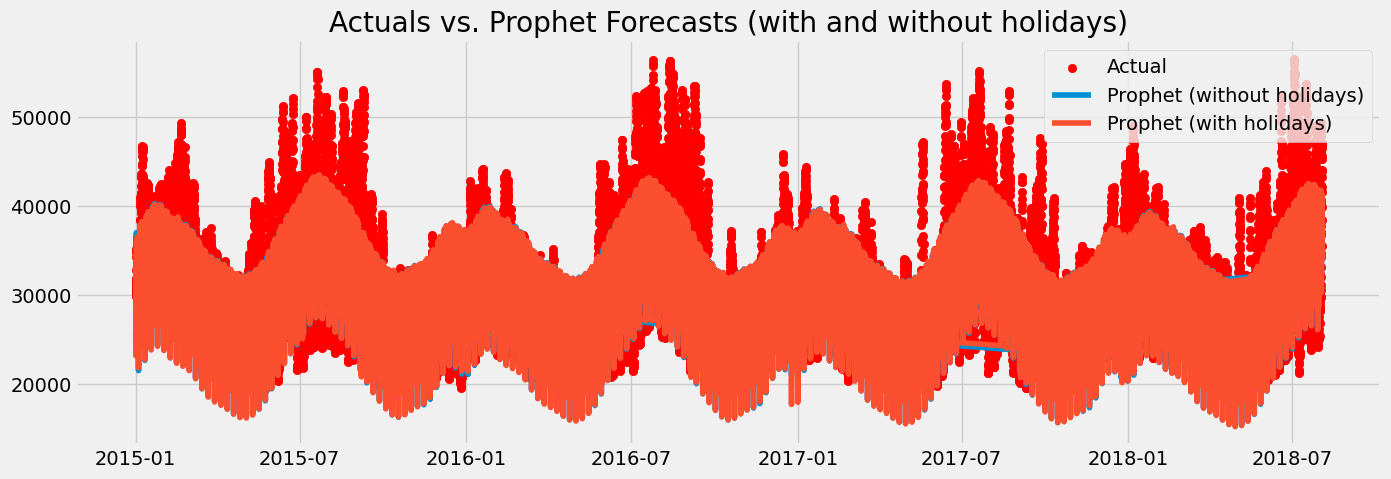

In [ ]:
# Align the actual values and predictions from both Prophet models for plotting
aligned_actual_plot, aligned_predicted_prophet_no_holidays = test_set['PJME_MW'].align(pjme_test_fcst_unique.set_index('ds')['yhat'], join='inner')
aligned_actual_plot, aligned_predicted_prophet_with_holidays = test_set['PJME_MW'].align(pjme_test_fcst_holidays.set_index('ds')['yhat'], join='inner')


f, ax = plt.subplots(1, figsize=(15, 5))
ax.scatter(aligned_actual_plot.index, aligned_actual_plot, color='r', label='Actual')
ax.plot(aligned_predicted_prophet_no_holidays.index, aligned_predicted_prophet_no_holidays, label='Prophet (without holidays)')
ax.plot(aligned_predicted_prophet_with_holidays.index, aligned_predicted_prophet_with_holidays, label='Prophet (with holidays)')

ax.set_title('Actuals vs. Prophet Forecasts (with and without holidays)')
ax.legend()
plt.show()

In [ ]:
# Use make_future_dataframe to generate future dates from the end of the training data to the end of 2020
last_train_date = train_set.index.max()
future_end_date = pd.to_datetime('2020-12-31 23:00:00') # End of 2020 at the last hour
# Calculate the number of hours from the last training date to the end of 2020
periods = int((future_end_date - last_train_date).total_seconds() / 3600)

future = model_with_holidays.make_future_dataframe(periods=periods, freq='h')

# Predict on the future dataframe
forecast = model_with_holidays.predict(future)

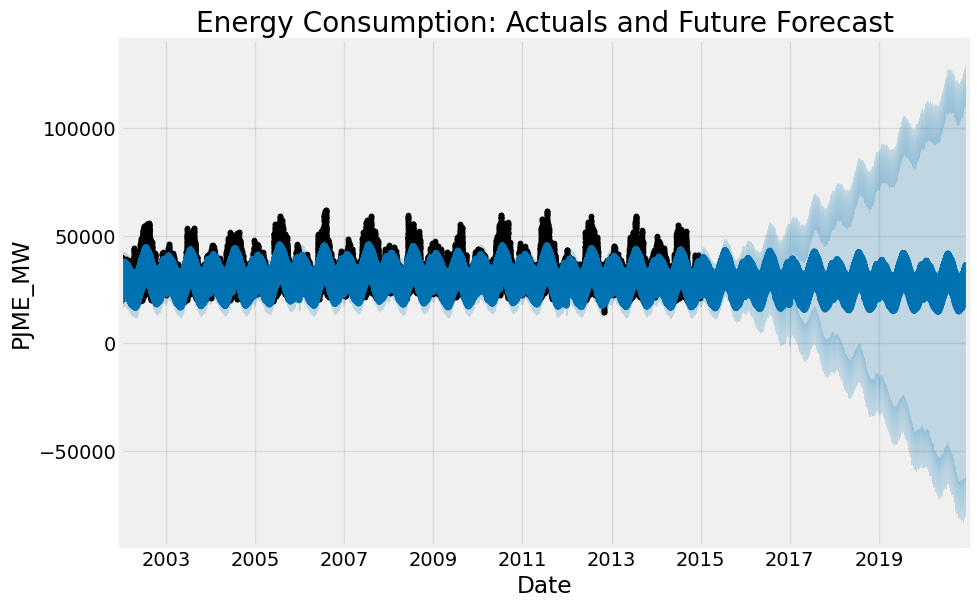

In [ ]:
# Plot the forecast with the actuals
fig = model_with_holidays.plot(forecast)
plt.title('Energy Consumption: Actuals and Future Forecast')
plt.xlabel('Date')
plt.ylabel('PJME_MW')
# Set the x-axis limits to include the entire forecast range
plt.xlim([forecast['ds'].min(), forecast['ds'].max()])
plt.show()

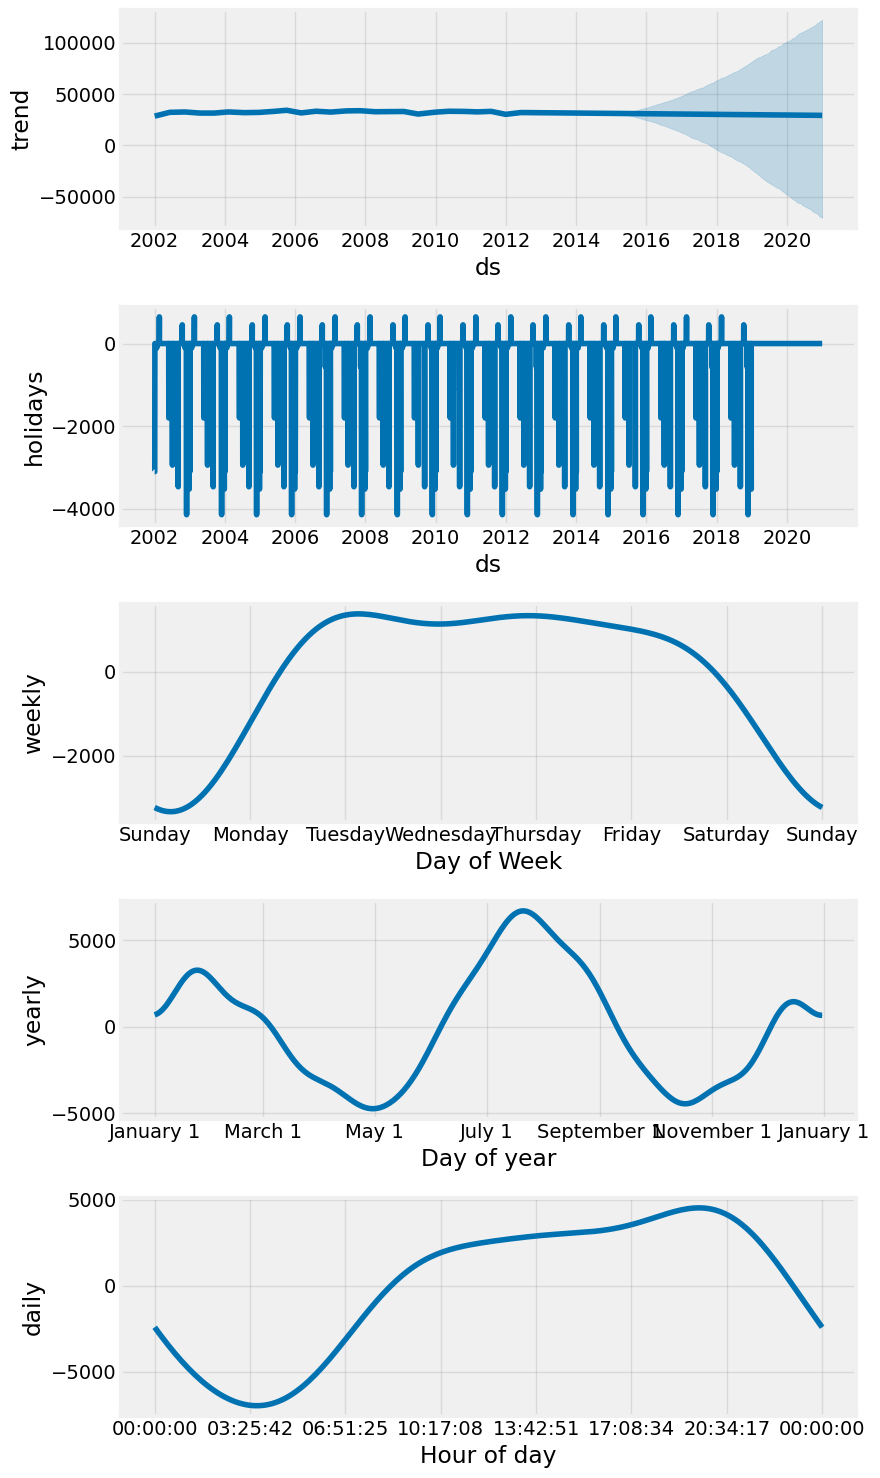

In [ ]:
# Plot the forecast components, including holidays
fig2 = model_with_holidays.plot_components(forecast)
plt.show()